In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
arg_raw <- read.csv("final_resistome_matrix.csv", row.names=1, check.names = FALSE)

In [3]:
arg_t <- t(arg_raw)
arg_df <- as.data.frame(arg_t)

In [4]:
# Normalize data to Counts Per Million (CPM) to account for sequencing depth.
arg_cpm <- arg_df %>%
    mutate_all(function (x) (x / sum(x)) * 1e6)
    # if cpm calc is NA then replace with 0
arg_cpm[is.na(arg_cpm)] <- 0

#apply log transformation
arg_log <- log10(arg_cpm + 1)  # Adding 1 to avoid log(0)
    


In [5]:
# calculate total resitome load
total_load <- data.frame(SampleID = rownames(arg_log),
                         Total_Resistome_Load = rowSums(arg_log))

In [6]:
total_load
#write csv
write.csv(total_load, "total_resistome_load.csv", row.names = FALSE)

,SampleID,Total_Resistome_Load
,<chr>,<dbl>
25617X10_S56,25617X10_S56,186.71329
25617X11_S57,25617X11_S57,145.12268
25617X12_S58,25617X12_S58,580.70285
25617X13_S59,25617X13_S59,619.58512
25617X14_S60,25617X14_S60,1153.83342
25617X15_S61,25617X15_S61,727.06824
25617X16_S62,25617X16_S62,1066.81706
25617X17_S63,25617X17_S63,1083.52707
25617X19_S65,25617X19_S65,906.68442


In [7]:
# rename total_load sample ids:
# for 25617 samples just keep everything before the first underscore
# for 9428 samples convert to garrett_<sample number> where sample number is the number after the last underscore
total_load <- total_load %>%
    mutate(SampleID = case_when(
        grepl("^25617X", SampleID) ~ sub("_.*", "", SampleID),
        grepl("^9428", SampleID) ~ paste0("garrett_", sub(".*_(\\d+)$", "\\1", SampleID)),
        TRUE ~ SampleID  # Keep original if neither condition matches
    ))
total_load

,SampleID,Total_Resistome_Load
,<chr>,<dbl>
25617X10_S56,25617X10,186.71329
25617X11_S57,25617X11,145.12268
25617X12_S58,25617X12,580.70285
25617X13_S59,25617X13,619.58512
25617X14_S60,25617X14,1153.83342
25617X15_S61,25617X15,727.06824
25617X16_S62,25617X16,1066.81706
25617X17_S63,25617X17,1083.52707
25617X19_S65,25617X19,906.68442


In [8]:
#write csv
write.csv(total_load, "total_resistome_load_renamed.csv", row.names = FALSE)

In [9]:
# read tsv metadata file
metadata <- read_tsv("sample_metadata.tsv")

Rows: 157 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): sample, donor, tissue, condition, data_origin, sex
dbl (2): day, age

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
metadata

sample,donor,day,tissue,condition,data_origin,sex,age
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
garrett_1,g18,0,Fecal,Healthy,garrett,female,32
garrett_2,g17,0,Fecal,Healthy,garrett,male,30
garrett_3,g10,0,Fecal,FMT,garrett,female,32
garrett_4,g3,0,Fecal,FMT,garrett,female,58
garrett_5,g3,56,Fecal,FMT,garrett,female,58
garrett_6,g19,14,Fecal,Healthy,garrett,female,61
garrett_7,g7,56,Fecal,FMT,garrett,male,40
garrett_8,g12,0,Fecal,FMT,garrett,male,64
garrett_9,g1,56,Fecal,FMT,garrett,female,50


In [11]:
# Merge the load data with the metadata for plotting
# The 'Sample_ID' column in load_data now matches 'row.names' in metadata
load_data <- merge(total_load, metadata, by.x = "SampleID", by.y = "sample")

In [12]:
#write csv
write.csv(load_data, "total_resistome_load_with_metadata.csv", row.names = FALSE)

In [13]:
load_data

SampleID,Total_Resistome_Load,donor,day,tissue,condition,data_origin,sex,age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
25617X1,755.96532,m22,0,Fecal,Healthy,mary,female,27
25617X10,186.71329,m26,14,Fecal,FMT,mary,male,33
25617X11,145.12268,m26,56,Fecal,FMT,mary,male,33
25617X12,580.70285,m31,0,Fecal,Healthy,mary,male,NA
25617X13,619.58512,m31,14,Fecal,Healthy,mary,male,NA
25617X14,1153.83342,m32,0,Fecal,FMT,mary,female,51
25617X15,727.06824,m33,0,Fecal,FMT,mary,male,83
25617X16,1066.81706,m38,0,Fecal,FMT,mary,male,36
25617X17,1083.52707,m38,14,Fecal,FMT,mary,male,36


In [14]:
# Plot the Total Resistome Load by Group
load_plot <- ggplot(load_data, aes(x = tissue, y = Total_Resistome_Load, fill = tissue)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7) +
  labs(
    title = "Total Resistome Load by Sample Group (Log-transformed CPM)",
    y = "Total ARG Abundance (Sum of Log10(CPM + 1))",
    x = "Sample Group"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


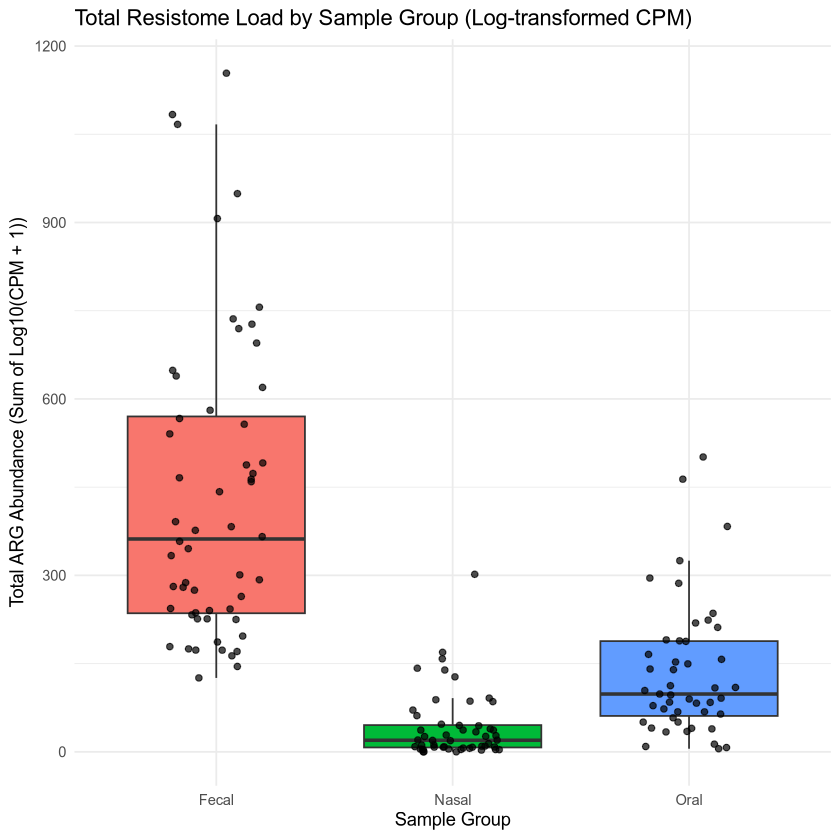

In [15]:
load_plot

In [16]:
# only load fecal data
load_data_fecal <- load_data %>%
    filter(tissue == "Fecal") %>%
    filter(condition == "FMT")

In [17]:
#Plot total resistome by day
load_plot_fecal <- ggplot(load_data_fecal, aes(x = as.factor(day), y = Total_Resistome_Load, fill = as.factor(day))) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7) +
  labs(
    title = "Total Resistome Load in Fecal Samples Over Time (Log-transformed CPM)",
    y = "Total ARG Abundance (Sum of Log10(CPM + 1))",
    x = "Day"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

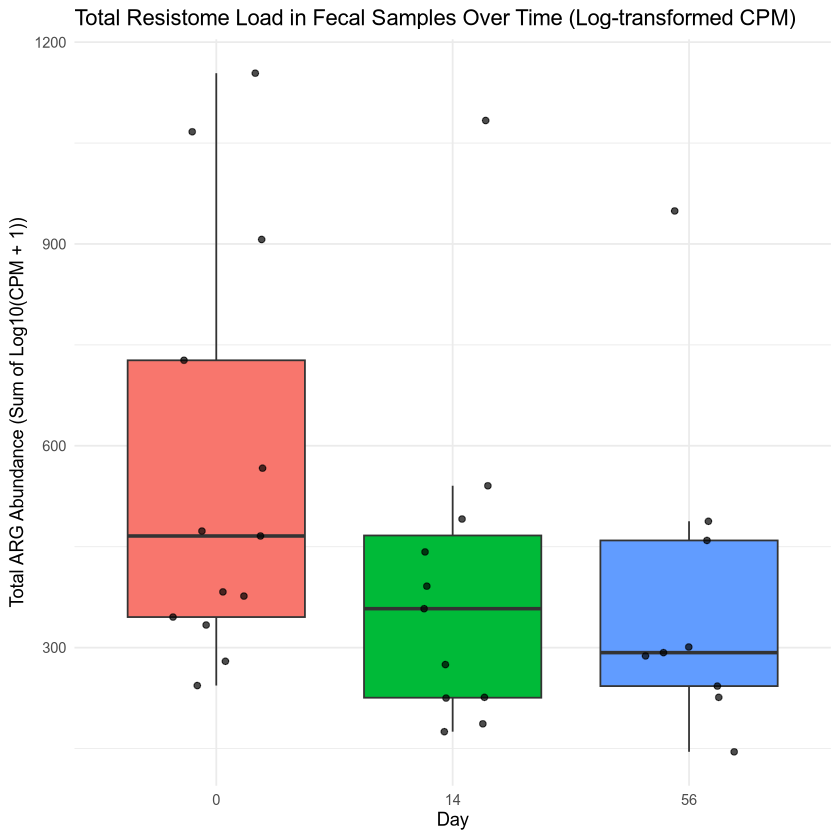

In [18]:
load_plot_fecal

In [19]:
#load nasal data
load_data_nasal <- load_data %>%
    filter(tissue == "Nasal") %>%
    filter(condition == "FMT")

In [20]:
#plot total resistome by day for nasal
load_plot_nasal <- ggplot(load_data_nasal, aes(x = as.factor(day), y = Total_Resistome_Load, fill = as.factor(day))) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha =  0.7) +
  labs(
    title = "Total Resistome Load in Nasal Samples Over Time (Log-transformed CPM)",
    y = "Total ARG Abundance (Sum of Log10(CPM + 1))",
    x = "Day"
  ) +
  theme_minimal() +     
    theme(legend.position = "none")
    

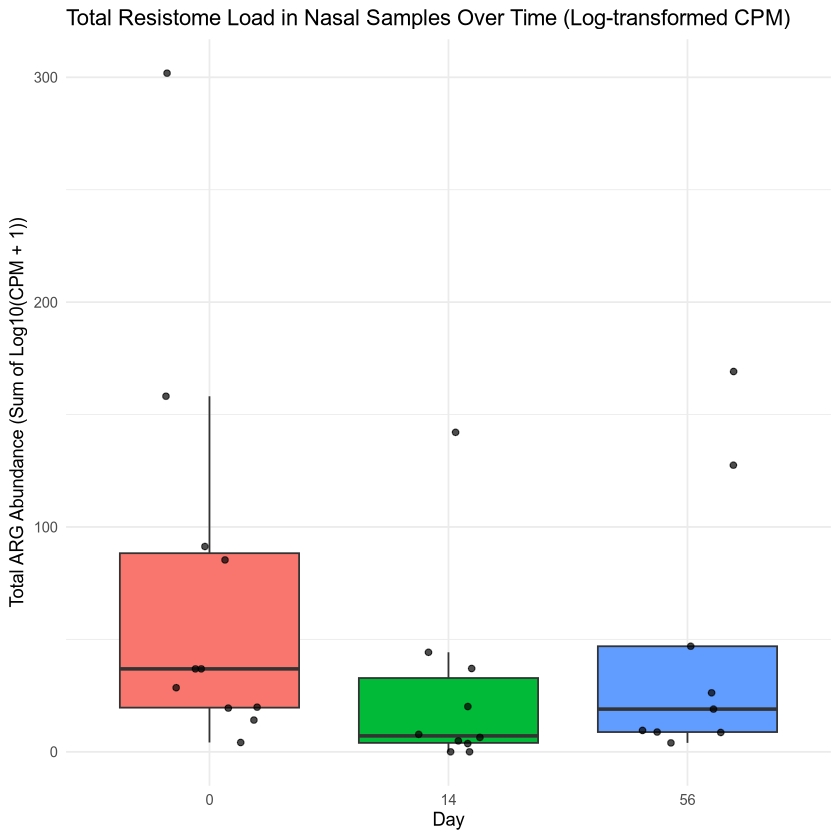

In [21]:
load_plot_nasal

In [22]:
# load oral data
load_data_oral <- load_data %>%
    filter(tissue == "Oral") %>%
    filter(condition == "FMT")    

In [23]:
# plot total resistome by day for oral
load_plot_oral <- ggplot(load_data_oral, aes(x = as.factor(day), y = Total_Resistome_Load, fill = as.factor(day))) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7) +
  labs(
    title = "Total Resistome Load in Oral Samples Over Time (Log-transformed CPM)",
    y = "Total ARG Abundance (Sum of Log10(CPM + 1))",
    x = "Day"
  ) +
  theme_minimal() +
    theme(legend.position = "none")

## ARG Load Boxplots by Tissue -- Styled to Match Manuscript Figure 7 Layout

Tissue-specific box colors (Fecal = red, Oral = blue, Nasal = green), shared neutral color for the Healthy reference group across all three panels. **No significance brackets are added here** -- the corrected tissue-stratified LMM (`posthoc_arg_by_tissue`, above) found no significant pairwise differences in any tissue, so this figure intentionally does not reproduce the asterisks from the original (uncorrected) manuscript figure.

In [24]:
# ---- Build ARG load data per tissue, including Healthy as a reference group ----
build_load_data_tissue <- function(tissue_name, load_data) {
  load_data %>%
    filter(tissue == tissue_name) %>%
    mutate(group_label = case_when(
      condition == "Healthy" ~ "Healthy",
      day == 0  ~ "Pre-FMT\nD0",
      day == 14 ~ "Post-FMT\nD14",
      day == 56 ~ "Post-FMT\nD56"
    )) %>%
    mutate(group_label = factor(group_label,
                                 levels = c("Pre-FMT\nD0", "Post-FMT\nD14", "Post-FMT\nD56", "Healthy")))
}

load_data_fecal_full <- build_load_data_tissue("Fecal", load_data)
load_data_oral_full  <- build_load_data_tissue("Oral",  load_data)
load_data_nasal_full <- build_load_data_tissue("Nasal", load_data)


In [25]:
# ---- Color palette: darker-to-lighter shade per tissue for FMT timepoints,
#      shared neutral "Healthy" color across all three panels ----
tissue_palette <- list(
  Fecal = c("Pre-FMT\nD0" = "#e04c4c", "Post-FMT\nD14" = "#f2a3a3", "Post-FMT\nD56" = "#f7cccc", "Healthy" = "#a3a06b"),
  Oral  = c("Pre-FMT\nD0" = "#4c6ee0", "Post-FMT\nD14" = "#a3b8f2", "Post-FMT\nD56" = "#cce0f7", "Healthy" = "#a3a06b"),
  Nasal = c("Pre-FMT\nD0" = "#3fa34c", "Post-FMT\nD14" = "#a3e0ab", "Post-FMT\nD56" = "#cceccf", "Healthy" = "#a3a06b")
)

plot_arg_load_panel <- function(df, tissue_name, panel_label) {
  ggplot(df, aes(x = group_label, y = Total_Resistome_Load, fill = group_label)) +
    geom_boxplot(outlier.shape = NA, color = "black", width = 0.6) +
    geom_jitter(width = 0.15, size = 1.3, alpha = 0.7, color = "black") +
    scale_fill_manual(values = tissue_palette[[tissue_name]]) +
    labs(x = NULL, y = " ", tag = panel_label) +
    theme_minimal(base_size = 12) +
    theme(
      legend.position = "none",
      axis.text.x = element_text(size = 9),
      plot.tag = element_text(face = "bold", size = 14),
      plot.tag.position = c(0.02, 0.98),
      plot.margin = margin(t = 20, r = 5, b = 5, l = 5)
    )
}


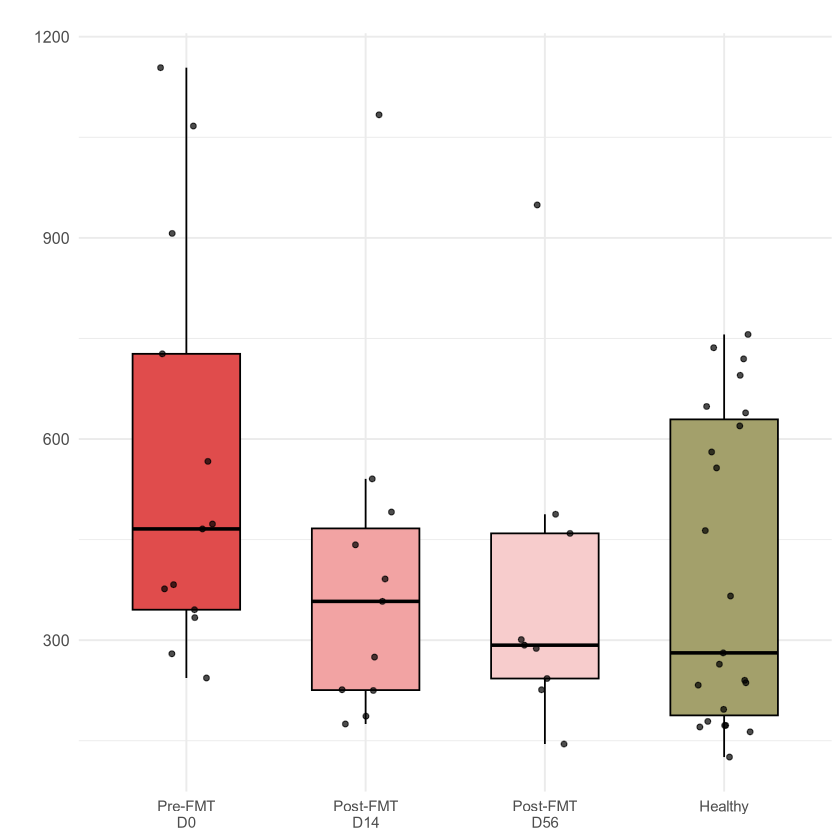

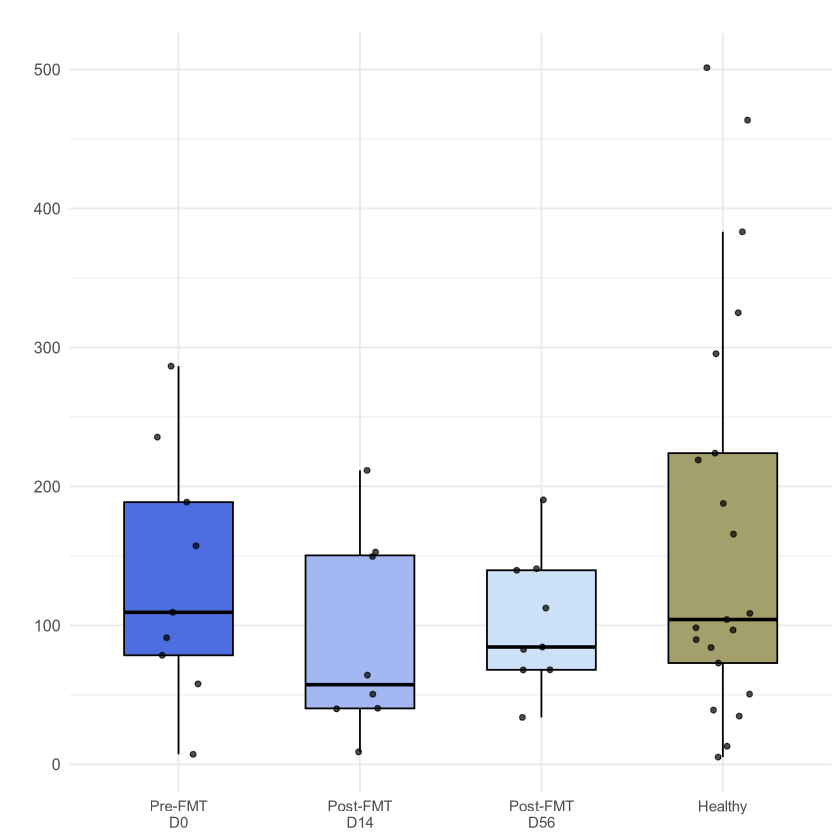

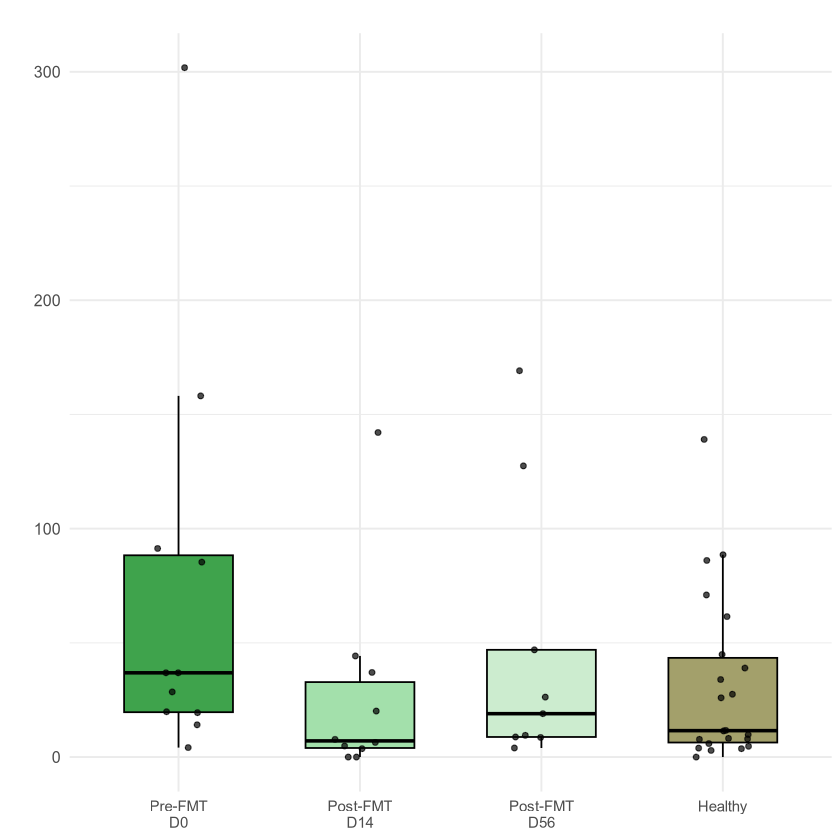

In [26]:
# ---- Separate, individually-printed and individually-saved plots (no combined panel) ----
p_fecal <- plot_arg_load_panel(load_data_fecal_full, "Fecal", NULL)
p_oral  <- plot_arg_load_panel(load_data_oral_full,  "Oral",  NULL)
p_nasal <- plot_arg_load_panel(load_data_nasal_full, "Nasal", NULL)

p_fecal
ggsave("ARG_load_Fecal.png", p_fecal, width = 6, height = 5, dpi = 300, bg = "white")

p_oral
ggsave("ARG_load_Oral.png", p_oral, width = 6, height = 5, dpi = 300, bg = "white")

p_nasal
ggsave("ARG_load_Nasal.png", p_nasal, width = 6, height = 5, dpi = 300, bg = "white")


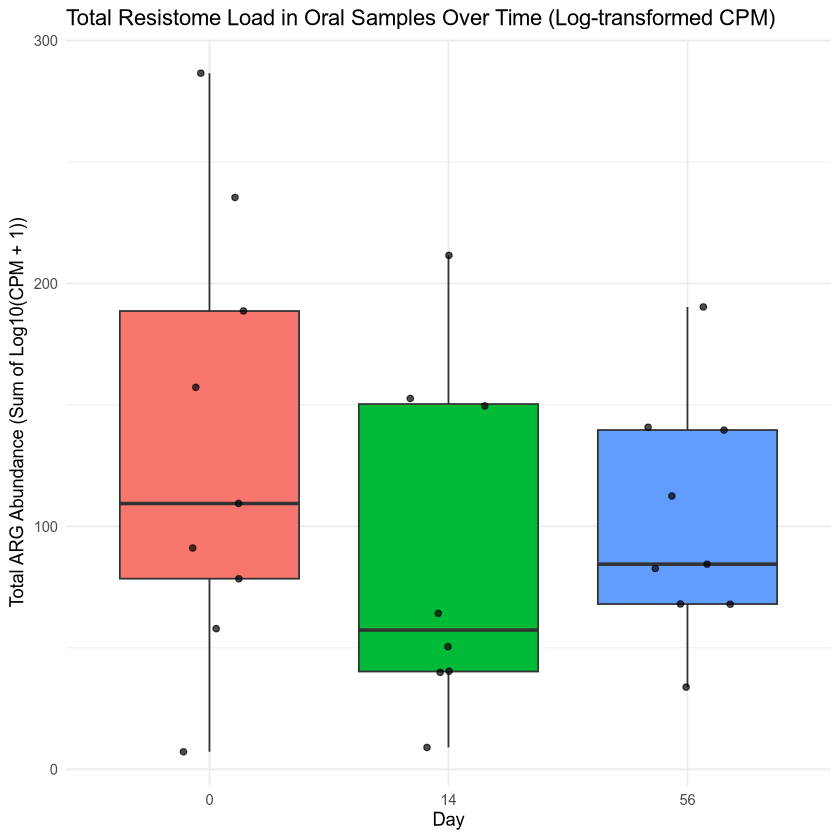

In [27]:
load_plot_oral

## Linear Mixed-Effects Model: Total Resistome Load (ARG Abundance), Tissue-Stratified

Same structure as the Shannon diversity and richness analyses: one model per tissue (Fecal / Oral / Nasal), Healthy excluded from the statistical model (kept only as a visual reference in the box plots above), fixed effects `condition_day_group + sex [+ age]`, random intercept `(1 | subject_id)`, and Tukey-adjusted post-hoc pairwise comparisons via `emmeans`.

In [28]:
# Load required packages (install once if needed):
# install.packages(c("lme4", "lmerTest", "emmeans"))
library(lme4)
library(lmerTest)
library(emmeans)


Loading required package: Matrix




Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [29]:
# ---- Prepare data for the ARG model ----
# Excluding Healthy from the model itself, same approach as the Shannon/richness models --
# Healthy remains in the box plots above as a visual reference only.
lme_df_arg <- load_data[load_data$condition != "Healthy", ]

lme_df_arg <- lme_df_arg %>%
  mutate(condition_day_group = case_when(
    day == 0  ~ "Pre-FMT",
    day == 14 ~ "FMT Day 14",
    day == 56 ~ "FMT Day 56"
  )) %>%
  mutate(condition_day_group = factor(condition_day_group,
                                       levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56")))

lme_df_arg$subject_id <- as.factor(lme_df_arg$donor)
lme_df_arg$sex        <- as.factor(lme_df_arg$sex)

# Check whether an 'age' column exists in the merged metadata
has_age_arg <- "age" %in% colnames(lme_df_arg)
if (!has_age_arg) {
  message("No 'age' column was found in load_data / sample_metadata.tsv.\n",
          "The model below will be fit WITHOUT age as a fixed effect.")
} else {
  lme_df_arg$age <- as.numeric(lme_df_arg$age)
}


In [30]:
# ---- Helper: fit the ARG-load LMM within a single tissue ----
fit_tissue_lmm_arg <- function(tissue_name) {
  d <- subset(lme_df_arg, tissue == tissue_name)
  d$condition_day_group <- droplevels(d$condition_day_group)
  d$sex <- droplevels(d$sex)

  cat("====", tissue_name, "====\n")
  cat("N obs:", nrow(d), "| N subjects:", length(unique(d$subject_id)), "\n\n")

  fixed_terms <- c("condition_day_group", "sex")
  if (has_age_arg) fixed_terms <- c(fixed_terms, "age")
  f <- as.formula(paste("Total_Resistome_Load ~", paste(fixed_terms, collapse = " + "), "+ (1 | subject_id)"))

  m <- lmer(f, data = d)
  list(model = m, data = d)
}


In [31]:
# ---- Fecal ----
fecal_arg_fit <- fit_tissue_lmm_arg("Fecal")
summary(fecal_arg_fit$model)


==== Fecal ====
N obs: 33 | N subjects: 13 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 394.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.26080 -0.39995 -0.04546  0.09292  2.43599 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 88852    298.1   
 Residual               15973    126.4   
Number of obs: 33, groups:  subject_id, 13

Fixed effects:
                              Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)                    429.399    304.609   10.149   1.410   0.1885  
condition_day_groupFMT Day 14 -104.654     53.659   17.583  -1.950   0.0673 .
condition_day_groupFMT Day 56  -64.999     57.833   17.745  -1.124   0.2760  
sexmale                        125.615    172.800    9.345   0.727   0.4851  
age                              1.580      5.731    9.901   0.276   0.7884  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Corr

In [32]:
anova(fecal_arg_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,61819.556,30909.778,2,17.579449,1.93512902,0.1739507
sex,8440.757,8440.757,1,9.344503,0.52843970,0.4850756
age,1214.300,1214.300,1,9.901500,0.07602214,0.7884309


In [33]:
# ---- Oral ----
oral_arg_fit <- fit_tissue_lmm_arg("Oral")
summary(oral_arg_fit$model)


==== Oral ====
N obs: 26 | N subjects: 11 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 251

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.83325 -0.56246 -0.05112  0.69468  1.65996 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 1811     42.56   
 Residual               2954     54.35   
Number of obs: 26, groups:  subject_id, 11

Fixed effects:
                              Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)                   162.3046    67.9590  10.3308   2.388   0.0373 *
condition_day_groupFMT Day 14 -44.3481    27.3911  15.3143  -1.619   0.1258  
condition_day_groupFMT Day 56 -32.0734    26.8648  15.9864  -1.194   0.2499  
sexmale                        35.6689    34.9929   8.0838   1.019   0.3376  
age                            -0.9891     1.1624   9.4718  -0.851   0.4158  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correl

In [34]:
anova(oral_arg_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,8264.869,4132.434,2,15.121200,1.3990906,0.2770167
sex,3068.884,3068.884,1,8.083801,1.0390115,0.3375850
age,2138.501,2138.501,1,9.471759,0.7240181,0.4158214


In [35]:
# ---- Nasal ----
nasal_arg_fit <- fit_tissue_lmm_arg("Nasal")
summary(nasal_arg_fit$model)


==== Nasal ====
N obs: 30 | N subjects: 12 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 292.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9915 -0.2915  0.0236  0.1620  3.2399 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 2375     48.74   
 Residual               2260     47.54   
Number of obs: 30, groups:  subject_id, 12

Fixed effects:
                              Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)                   132.2684    60.7951  12.6251   2.176   0.0492 *
condition_day_groupFMT Day 14 -49.4663    21.6475  18.0566  -2.285   0.0346 *
condition_day_groupFMT Day 56 -31.7932    22.4379  18.3670  -1.417   0.1732  
sexmale                        -0.4635    33.6163   9.7789  -0.014   0.9893  
age                            -1.2805     1.1400  11.5520  -1.123   0.2842  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of

In [36]:
anova(nasal_arg_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,1.202561e+04,6012.8036225,2,17.821042,2.6608968449,0.09745477
sex,4.295095e-01,0.4295095,1,9.778876,0.0001900745,0.98927733
age,2.850757e+03,2850.7570966,1,11.552007,1.2615696504,0.28415493


In [37]:
# ---- Omnibus group/timepoint effect, side-by-side across tissues (ARG load) ----
extract_group_effect_arg <- function(fit, tissue_name) {
  a <- anova(fit$model)
  vc <- as.data.frame(VarCorr(fit$model))
  icc <- vc$vcov[vc$grp == "subject_id"] / sum(vc$vcov)
  data.frame(tissue = tissue_name,
             n_obs = nrow(fit$data),
             n_subjects = length(unique(fit$data$subject_id)),
             ICC = round(icc, 3),
             group_F = a["condition_day_group", "F value"],
             group_p = a["condition_day_group", "Pr(>F)"])
}

arg_group_effect_summary <- rbind(
  extract_group_effect_arg(fecal_arg_fit, "Fecal"),
  extract_group_effect_arg(oral_arg_fit,  "Oral"),
  extract_group_effect_arg(nasal_arg_fit, "Nasal")
)
arg_group_effect_summary


tissue,n_obs,n_subjects,ICC,group_F,group_p
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
Fecal,33,13,0.848,1.935129,0.17395072
Oral,26,11,0.380,1.399091,0.27701668
Nasal,30,12,0.512,2.660897,0.09745477


In [38]:
# ---- Tukey-adjusted pairwise comparisons across timepoint, within each tissue (ARG load) ----
posthoc_arg_by_tissue <- rbind(
  as.data.frame(emmeans(fecal_arg_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Fecal"),
  as.data.frame(emmeans(oral_arg_fit$model,  pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Oral"),
  as.data.frame(emmeans(nasal_arg_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Nasal")
)
posthoc_arg_by_tissue <- posthoc_arg_by_tissue[, c("tissue", setdiff(names(posthoc_arg_by_tissue), "tissue"))]
posthoc_arg_by_tissue


tissue,contrast,estimate,SE,df,t.ratio,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fecal,(Pre-FMT) - FMT Day 14,104.65446,53.78519,18.30129,1.9457860,0.15434965
Fecal,(Pre-FMT) - FMT Day 56,64.99876,58.04428,18.45783,1.1198133,0.51429472
Fecal,FMT Day 14 - FMT Day 56,-39.65570,58.16772,18.13731,-0.6817475,0.77691027
Oral,(Pre-FMT) - FMT Day 14,44.34809,27.87746,15.00753,1.5908225,0.27975265
Oral,(Pre-FMT) - FMT Day 56,32.07345,27.48716,15.70343,1.1668518,0.48923137
Oral,FMT Day 14 - FMT Day 56,-12.27464,26.89962,13.91938,-0.4563129,0.89243084
Nasal,(Pre-FMT) - FMT Day 14,49.46631,21.86506,17.29282,2.2623454,0.08858417
Nasal,(Pre-FMT) - FMT Day 56,31.79321,22.73155,17.62343,1.3986378,0.36291068
Nasal,FMT Day 14 - FMT Day 56,-17.67310,22.09972,16.33191,-0.7996979,0.70843455


**What this section adds:**
- Three tissue-stratified LMMs on `Total_Resistome_Load` (log10-CPM summed across ARGs), same fixed/random-effect structure as the Shannon/richness models, Healthy excluded from the statistical comparison.
- `arg_group_effect_summary` -- omnibus F-test and ICC for `condition_day_group`, per tissue.
- `posthoc_arg_by_tissue` -- Tukey-adjusted pairwise comparisons among Pre-FMT / Day 14 / Day 56, per tissue.

This replaces whatever produced the asterisks in the manuscript's Figure 7 (Fecal and Nasal panels) with a repeated-measures-appropriate model, matching how Figure 2 was handled.

## Effect Size Forest Plot: Fixed-Effect Estimates (ARG Load), by Tissue

Forest plot of the fixed-effect coefficients (not Tukey-adjusted `emmeans` contrasts) from the three tissue-stratified ARG-load LMMs: `condition_day_group` (FMT Day 14 vs Pre-FMT, FMT Day 56 vs Pre-FMT), `sex`, and `age`, each with raw Wald 95% CIs and unadjusted (Satterthwaite) p-values from `lmerTest`. Styled to match the `Fixed-Effect Estimates` forest plot used elsewhere in the manuscript (left-hand estimate/CI text column + point-range panel, colored by tissue, filled point = p < 0.05, open point = n.s.).

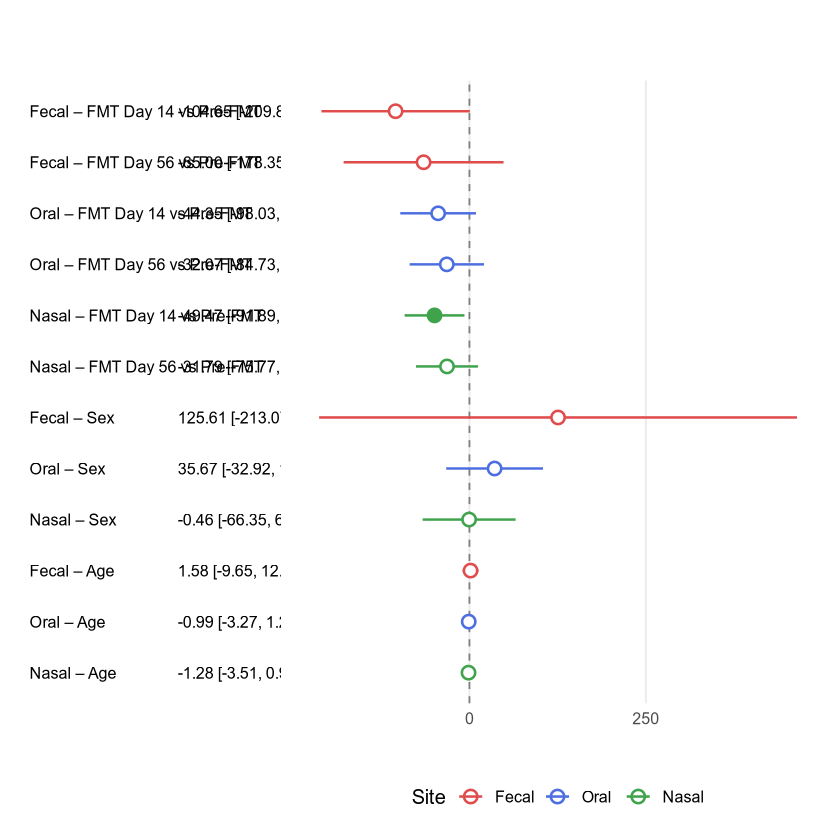

In [39]:
# ---- Forest plot: Fixed-effect estimates (ARG load), raw (unadjusted) p-values ----
library(ggplot2)
library(patchwork)   # install.packages("patchwork") if not already installed

# ---- Extract fixed-effect coefficients + Wald 95% CIs directly from each tissue model ----
# (No emmeans / no Tukey adjustment -- these are the raw model coefficients and
#  lmerTest's Satterthwaite p-values, same as summary(model).)
extract_fixef_arg <- function(fit, tissue_name) {
  model <- fit$model
  coefs <- summary(model)$coefficients
  ci    <- confint(model, parm = "beta_", method = "Wald")

  data.frame(
    term      = rownames(coefs),
    estimate  = coefs[, "Estimate"],
    p.value   = coefs[, "Pr(>|t|)"],
    conf.low  = ci[, 1],
    conf.high = ci[, 2],
    tissue    = tissue_name,
    row.names = NULL
  ) %>%
    filter(term != "(Intercept)")
}

arg_fixef_df <- bind_rows(
  extract_fixef_arg(fecal_arg_fit, "Fecal"),
  extract_fixef_arg(oral_arg_fit,  "Oral"),
  extract_fixef_arg(nasal_arg_fit, "Nasal")
)

# ---- Clean up term labels, build row order + display text ----
arg_fixef_df <- arg_fixef_df %>%
  mutate(
    term_clean = case_when(
      grepl("Day 14", term) ~ "FMT Day 14 vs Pre-FMT",
      grepl("Day 56", term) ~ "FMT Day 56 vs Pre-FMT",
      grepl("^sex", term, ignore.case = TRUE) ~ "Sex",
      term == "age" ~ "Age",
      TRUE ~ term
    ),
    term_rank = case_when(
      term_clean == "FMT Day 14 vs Pre-FMT" ~ 1,
      term_clean == "FMT Day 56 vs Pre-FMT" ~ 2,
      term_clean == "Sex" ~ 3,
      term_clean == "Age" ~ 4,
      TRUE ~ 5
    ),
    tissue    = factor(tissue, levels = c("Fecal", "Oral", "Nasal")),
    row_label = paste0(tissue, " \u2013 ", term_clean),
    sig       = ifelse(p.value < 0.05, "p < 0.05", "n.s."),
    label_text = sprintf("%.2f [%.2f, %.2f]", estimate, conf.low, conf.high)
  )
  # ---- Row order: timepoint comparisons grouped by tissue first, Sex/Age unchanged ----
arg_fixef_df <- arg_fixef_df %>%
  mutate(block = ifelse(term_rank <= 2, "contrast", "covariate"))

contrast_rows  <- arg_fixef_df %>% filter(block == "contrast")  %>% arrange(tissue, term_rank)
covariate_rows <- arg_fixef_df %>% filter(block == "covariate") %>% arrange(term_rank, tissue)

arg_fixef_df <- bind_rows(contrast_rows, covariate_rows) %>%
  select(-block)

row_order <- rev(unique(arg_fixef_df$row_label))
arg_fixef_df$row_label <- factor(arg_fixef_df$row_label, levels = row_order)


# ---- Site colors + open/filled fill logic (matches the Fixed-Effect Estimates theme) ----
tissue_colors <- c(Fecal = "#e04c4c", Oral = "#4c6ee0", Nasal = "#3fa34c")

arg_fixef_df <- arg_fixef_df %>%
  mutate(
    point_color = tissue_colors[as.character(tissue)],
    point_fill  = ifelse(sig == "p < 0.05", point_color, "white")
  )

# ---- Left panel: contrast/row label + Estimate [95% CI] text, two aligned columns ----
label_panel <- ggplot(arg_fixef_df, aes(y = row_label)) +
  geom_text(aes(x = 0,    label = row_label),  hjust = 0, size = 3.4, family = "sans") +
  geom_text(aes(x = 2.05, label = label_text), hjust = 0, size = 3.4, family = "sans") +
  scale_x_continuous(limits = c(0, 3.3)) +
  theme_void(base_size = 12) +
  theme(plot.margin = margin(t = 25, r = 0, b = 5, l = 5))

# ---- Right panel: forest plot ----
forest_panel <- ggplot(arg_fixef_df, aes(x = estimate, y = row_label)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high, color = tissue), height = 0, linewidth = 0.7) +
  geom_point(aes(fill = point_fill, color = tissue), shape = 21, size = 3, stroke = 1.1) +
  scale_fill_identity() +
  scale_color_manual(values = tissue_colors, name = "Site") +
  labs(x = " ", y = NULL, title = " ") +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, size = 13, face = "bold"),
    legend.position = "bottom"
)

# # ---- Dummy layer purely to get a clean Significance legend (open vs filled) ----
# sig_legend_df <- data.frame(x = 0, y = row_order[1], sig = c("n.s.", "p < 0.05"))
# forest_panel <- forest_panel +
#   geom_point(data = sig_legend_df, aes(x = x, y = y, shape = sig),
#              color = "black", fill = c("white", "black"), size = 3, stroke = 1.1, inherit.aes = FALSE) +
#   scale_shape_manual(values = c("n.s." = 21, "p < 0.05" = 21), name = "Significance") +
#   guides(shape = guide_legend(override.aes = list(fill = c("white", "black"), color = "black")))

# ---- Combine into one figure ----
arg_forest_combo <- label_panel + forest_panel +
  plot_layout(widths = c(1, 2)) +
  plot_annotation(
    #title = "Fixed-Effect Estimates",
    theme = theme(plot.title = element_text(size = 18, hjust = 0))
  )

arg_forest_combo

ggsave("ARG_load_fixed_effect_forest_plot.png", plot = arg_forest_combo, width = 12, height = 6, dpi = 300, bg = "white")

In [40]:
table(lme_df_arg$sex[lme_df_arg$tissue == "Fecal"], lme_df_arg$subject_id[lme_df_arg$tissue == "Fecal"])

        
         g1 g10 g12 g15 g3 g4 g7 g8 m26 m32 m33 m38 m39
  female  3   2   0   3  3  3  0  3   0   1   0   0   0
  male    0   0   3   0  0  0  3  0   3   0   1   2   3

**Reading the plot:** each row is a fixed-effect coefficient from the tissue-specific ARG-load LMM (`FMT Day 14 vs Pre-FMT`, `FMT Day 56 vs Pre-FMT`, `Sex`, `Age`); the point is the estimate and the bar is the raw (unadjusted) Wald 95% CI. Filled points denote unadjusted p < 0.05; open points denote n.s. No comparison in any tissue reaches significance and every CI spans zero, consistent with the omnibus LMM and pairwise results reported elsewhere -- this replaces the manuscript's prior claim of a significant ARG decrease.

In [41]:
library(tidyverse)

# 1. Load your existing ARO matrix
arg_matrix <- read.csv("final_resistome_matrix.csv", row.names = 1)

# 2. Load the drug class mapping
arg_map <- read.csv("arg_class_map.csv")

# 3. Convert matrix to long format
aro_long <- arg_matrix %>%
  rownames_to_column("ARO_Term") %>%
  pivot_longer(cols = -ARO_Term, 
               names_to = "sample_id", 
               values_to = "reads")

# 4. Join with drug class mapping
aro_with_class <- aro_long %>%
  left_join(arg_map, by = c("ARO_Term" = "ARO_Term"))

# 5. Split drug classes (key step!)
aro_by_class <- aro_with_class %>%
  separate_rows(Drug_Class, sep = "; ") %>%
  mutate(Drug_Class = trimws(Drug_Class)) %>%
  # Simplify names
  mutate(Drug_Class = str_remove(Drug_Class, " antibiotic$| beta-lactam$"))

# 6. Sum reads by drug class and sample
drug_class_counts <- aro_by_class %>%
  group_by(Drug_Class, sample_id) %>%
  summarize(total_reads = sum(reads, na.rm = TRUE), .groups = "drop")

# 7. Convert back to matrix format
drug_class_matrix <- drug_class_counts %>%
  pivot_wider(names_from = sample_id, 
              values_from = total_reads, 
              values_fill = 0) %>%
  column_to_rownames("Drug_Class") %>%
  as.matrix()

# 8. Optional: Save the new matrix
write.csv(drug_class_matrix, "drug_class_counts_matrix.csv")

# 9. Log-transform for heatmap
drug_class_matrix_log <- log10(drug_class_matrix + 1)


In [42]:
# get rid of the first X in column names of drug_class_matrix_log
colnames(drug_class_matrix_log) <- ifelse(grepl("^X25617", colnames(drug_class_matrix_log)),
                                          sub("^X", "", colnames(drug_class_matrix_log)),
                                          ifelse(grepl("^X9428", colnames(drug_class_matrix_log)),
                                                 sub("^X", "", colnames(drug_class_matrix_log)),
                                                 colnames(drug_class_matrix_log)))  # Keep original if neither pattern matches

In [43]:
# for 25617 samples just keep everything before the first underscore
# for 9428 samples convert to garrett_<sample number> where sample number is the number after the last underscore
colnames(drug_class_matrix_log) <- ifelse(grepl("^25617X", colnames(drug_class_matrix_log)),
                                          sub("_.*", "", colnames(drug_class_matrix_log)),
                                          ifelse(grepl("^9428", colnames(drug_class_matrix_log)),
                                                 paste0("garrett_", sub(".*_(\\d+)$", "\\1", colnames(drug_class_matrix_log))),
                                                 colnames(drug_class_matrix_log)))  # Keep original if neither pattern matches

In [44]:
drug_class_matrix_log

,25617X10,25617X11,25617X12,25617X13,25617X14,25617X15,25617X16,25617X17,25617X19,25617X1,⋯,garrett_88,garrett_89,garrett_9,garrett_90,garrett_91,garrett_92,garrett_93,garrett_94,garrett_95,garrett_96
,0.0000000,0.0000000,0.0000000,0.000000,2.863323,0.0000000,0.000000,0.000000,2.5843312,0.301030,⋯,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
aminocoumarin,1.2041200,0.6989700,0.0000000,0.000000,4.413249,1.5563025,3.914925,3.828595,4.3869268,1.579784,⋯,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
aminoglycoside,0.8450980,1.2552725,2.7737864,2.787460,4.334494,2.8082110,3.909342,3.855398,4.3037143,3.063333,⋯,0.4771213,0.0000000,1.8061800,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,1.0000000
antibacterial free fatty acids,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
antibiotic without defined classification,0.0000000,0.0000000,0.0000000,0.301030,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
bicyclomycin-like,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
carbapenem,1.0791812,0.6020600,2.0413927,1.929419,4.498848,2.3856063,3.457428,3.282396,3.9823165,2.181844,⋯,0.4771213,0.4771213,1.3424227,0,0.0000000,0.4771213,0.00000,0.30103,0.0000000,0.0000000
cephalosporin,1.5563025,1.3802112,2.9148718,2.640481,4.693920,2.7839036,4.090470,4.098851,4.5298921,2.935507,⋯,0.6989700,0.6989700,2.3159703,0,0.0000000,0.0000000,0.00000,0.30103,1.4313638,1.8129134
diaminopyrimidine,0.9030900,1.3010300,2.8061800,2.752048,4.172048,1.2304489,1.230449,2.235528,3.4361626,2.998695,⋯,0.0000000,0.0000000,1.7923917,0,0.0000000,0.0000000,0.00000,0.00000,0.0000000,0.0000000
disinfecting agents and antiseptics,1.1139434,0.9030900,1.0413927,0.000000,4.410339,1.9867717,4.095274,3.990294,4.5167204,1.959041,⋯,0.4771213,0.0000000,1.4771213,0,0.0000000,0.4771213,0.00000,0.00000,0.0000000,0.7781513


In [45]:
#write csv
write.csv(drug_class_matrix_log, "all_drug_class_matrix_log_transformed.csv")

In [46]:
# keep only the top 25 drug classes by mean abundance
top_25_classes <- drug_class_matrix_log %>%
  rowMeans() %>%
  sort(decreasing = TRUE) %>%
  head(25) %>%
  names()
drug_class_matrix_log_top25 <- drug_class_matrix_log[top_25_classes, ]

In [47]:
#write csv
write.csv(drug_class_matrix_log_top25, "top_25_drug_class_matrix_log_transformed.csv")

In [48]:
library(pheatmap)
# Order samples by Condition first, then DAY, then donor
metadata_sorted <- metadata %>%
  # filter only fecal samples
  filter(tissue == "Fecal") %>%
  arrange(condition, day, donor)  # Added condition first

common_samples <- intersect(colnames(drug_class_matrix_log_top25), metadata_sorted$sample)
print(paste("Number of common samples:", length(common_samples)))
drug_class_matrix_log_subset <- drug_class_matrix_log_top25[, common_samples]
metadata_sorted <- metadata_sorted %>%
  filter(sample %in% common_samples)

# Reorder matrix
drug_class_matrix_log_sorted <- drug_class_matrix_log_subset[, metadata_sorted$sample]
# Order rows by abundance (most to least abundant)
# row_order <- order(rowMeans(drug_class_matrix_log_sorted), decreasing = TRUE)
# drug_class_matrix_log_sorted <- drug_class_matrix_log_sorted[row_order, ]

# Prepare annotation dataframe
anno_df <- data.frame(
  Tissue = metadata_sorted$tissue,
  Day = factor(metadata_sorted$day),
  Donor = metadata_sorted$donor,
  Condition = metadata_sorted$condition,
  row.names = metadata_sorted$sample
)

# Define colors (including donor colors)
# Create a color palette for donors
n_donors <- length(unique(metadata_sorted$donor))
donor_colors <- setNames(
  rainbow(n_donors),  # Or use a better palette
  sort(unique(metadata_sorted$donor))
)

# Define annotation colors
anno_colors <- list(
  Tissue = c(Fecal = 'brown', Oral = 'lightblue', Nasal = 'yellow'),
  Donor = donor_colors, 
  Day = c('0'='white', '14' = 'grey', '56' = 'black'),
  Condition = c(FMT = "purple", Healthy = "green")
)

# Create heatmap with clustering turned OFF for columns
pheatmap(
  drug_class_matrix_log_sorted,  # Use sorted matrix
  annotation_col = anno_df,
  annotation_colors = anno_colors,
  show_colnames = FALSE,
  show_rownames = TRUE,
  fontsize_row = 9,
  clustering_distance_rows = "euclidean",
  cluster_cols = FALSE,  # Turn off column clustering to maintain your order
  #cluster_rows = FALSE,
  clustering_method = "complete",
  color = colorRampPalette(c("white", "pink", "red"))(100),
  main = "AMR Gene Profiles by Drug Class (Fecal)",
  filename = "Fecal_AMR_Heatmap_pheatmap.png",
  width = 12,
  height = 8
)

[1] "Number of common samples: 56"


In [49]:
library(pheatmap)
# Order samples by Condition first, then DAY, then donor
metadata_sorted <- metadata %>%
  # filter only fecal samples
  filter(tissue == "Nasal") %>%
  arrange(condition, day, donor)  # Added condition first

common_samples <- intersect(colnames(drug_class_matrix_log_top25), metadata_sorted$sample)
print(paste("Number of common samples:", length(common_samples)))
drug_class_matrix_log_subset <- drug_class_matrix_log_top25[, common_samples]
metadata_sorted <- metadata_sorted %>%
  filter(sample %in% common_samples)

# Reorder matrix
drug_class_matrix_log_sorted <- drug_class_matrix_log_subset[, metadata_sorted$sample]
# Order rows by abundance (most to least abundant)
# row_order <- order(rowMeans(drug_class_matrix_log_sorted), decreasing = TRUE)
# drug_class_matrix_log_sorted <- drug_class_matrix_log_sorted[row_order, ]

# Prepare annotation dataframe
anno_df <- data.frame(
  Tissue = metadata_sorted$tissue,
  Day = factor(metadata_sorted$day),
  Donor = metadata_sorted$donor,
  Condition = metadata_sorted$condition,
  row.names = metadata_sorted$sample
)

# Define colors (including donor colors)
# Create a color palette for donors
n_donors <- length(unique(metadata_sorted$donor))
donor_colors <- setNames(
  rainbow(n_donors),  # Or use a better palette
  sort(unique(metadata_sorted$donor))
)

# Define annotation colors
anno_colors <- list(
  Tissue = c(Fecal = 'brown', Oral = 'lightblue', Nasal = 'yellow'),
  Donor = donor_colors, 
  Day = c('0'='white', '14' = 'grey', '56' = 'black'),
  Condition = c(FMT = "purple", Healthy = "green")
)

# Create heatmap with clustering turned OFF for columns
pheatmap(
  drug_class_matrix_log_sorted,  # Use sorted matrix
  annotation_col = anno_df,
  annotation_colors = anno_colors,
  show_colnames = FALSE,
  show_rownames = TRUE,
  fontsize_row = 9,
  clustering_distance_rows = "euclidean",
  cluster_cols = FALSE,  # Turn off column clustering to maintain your order
  #cluster_rows = FALSE,
  clustering_method = "complete",
  color = colorRampPalette(c("white", "pink", "red"))(100),
  main = "AMR Gene Profiles by Drug Class (Nasal)",
  filename = "Nasal_AMR_Heatmap_pheatmap.png",
  width = 12,
  height = 8
)

[1] "Number of common samples: 52"


In [50]:
library(pheatmap)
# Order samples by Condition first, then DAY, then donor
metadata_sorted <- metadata %>%
  # filter only fecal samples
  filter(tissue == "Oral") %>%
  arrange(condition, day, donor)  # Added condition first

common_samples <- intersect(colnames(drug_class_matrix_log_top25), metadata_sorted$sample)
print(paste("Number of common samples:", length(common_samples)))
drug_class_matrix_log_subset <- drug_class_matrix_log_top25[, common_samples]
metadata_sorted <- metadata_sorted %>%
  filter(sample %in% common_samples)

# Reorder matrix
drug_class_matrix_log_sorted <- drug_class_matrix_log_subset[, metadata_sorted$sample]
# Order rows by abundance (most to least abundant)
# row_order <- order(rowMeans(drug_class_matrix_log_sorted), decreasing = TRUE)
# drug_class_matrix_log_sorted <- drug_class_matrix_log_sorted[row_order, ]

# Prepare annotation dataframe
anno_df <- data.frame(
  Tissue = metadata_sorted$tissue,
  Day = factor(metadata_sorted$day),
  Donor = metadata_sorted$donor,
  Condition = metadata_sorted$condition,
  row.names = metadata_sorted$sample
)

# Define colors (including donor colors)
# Create a color palette for donors
n_donors <- length(unique(metadata_sorted$donor))
donor_colors <- setNames(
  rainbow(n_donors),  # Or use a better palette
  sort(unique(metadata_sorted$donor))
)

# Define annotation colors
anno_colors <- list(
  Tissue = c(Fecal = 'brown', Oral = 'lightblue', Nasal = 'yellow'),
  Donor = donor_colors, 
  Day = c('0'='white', '14' = 'grey', '56' = 'black'),
  Condition = c(FMT = "purple", Healthy = "green")
)

# Create heatmap with clustering turned OFF for columns
pheatmap(
  drug_class_matrix_log_sorted,  # Use sorted matrix
  annotation_col = anno_df,
  annotation_colors = anno_colors,
  show_colnames = FALSE,
  show_rownames = TRUE,
  fontsize_row = 9,
  clustering_distance_rows = "euclidean",
  cluster_cols = FALSE,  # Turn off column clustering to maintain your order
  #cluster_rows = FALSE,
  clustering_method = "complete",
  color = colorRampPalette(c("white", "pink", "red"))(100),
  main = "AMR Gene Profiles by Drug Class (Oral)",
  filename = "Oral_AMR_Heatmap_pheatmap.png",
  width = 12,
  height = 8
)

[1] "Number of common samples: 47"
